# Covered-Call ETFs — is the 'income' free, or is it your own money? 💸
### JEPI, QYLD and friends pay a fat monthly yield — but where does it come from?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Yield_without_giving_up_returns%3F: Busted](https://img.shields.io/badge/Yield_without_giving_up_returns%3F-Busted-8b949e?style=flat-square)

Buy-write 'income' ETFs are everywhere: **JEPI**, **JEPQ**, **QYLD**, **XYLD**, **RYLD** — funds that hold the stock market, sell call options against it, and pay out an eye-catching **8–12% monthly yield**. The pitch is irresistible: *keep your equity returns, and collect a juicy income on top.* This notebook asks the only two questions that matter — **where does that 'income' actually come from, and do you really keep your returns?**

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap CIs and the capture math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-05-31).
# Used only on a cache miss so the notebook re-runs identically offline.
R = {'qyld_cagr': 8.1, 'qyld_t': -3.21, 'qyld_spread': -6.4, 'qyld_sh': 0.76, 'qyld_up': 0.6, 'qyld_dn': 0.62, 'qyld_n': 149, 'xyld_cagr': 8.0, 'xyld_t': -3.84, 'xyld_spread': -7.3, 'xyld_sh': 0.74, 'xyld_up': 0.63, 'xyld_dn': 0.71, 'xyld_n': 155, 'ryld_cagr': 5.0, 'ryld_t': -2.9, 'ryld_spread': -11.4, 'ryld_sh': 0.4, 'ryld_up': 0.57, 'ryld_dn': 0.76, 'ryld_n': 85, 'jepi_cagr': 10.4, 'jepi_t': -2.08, 'jepi_spread': -8.5, 'jepi_sh': 1.0, 'jepi_up': 0.6, 'jepi_dn': 0.62, 'jepi_n': 72, 'jepq_cagr': 17.7, 'jepq_t': -0.15, 'jepq_spread': -0.5, 'jepq_sh': 1.18, 'jepq_up': 0.93, 'jepq_dn': 0.88, 'jepq_n': 48, 'spy_cagr': 14.0, 'spy_sh': 0.95, 'qyld_dist': 11.2, 'qyld_price': -2.7, 'qyld_roc': 1.0, 'xyld_dist': 8.0, 'xyld_price': 0.1, 'xyld_roc': 0.99, 'ryld_dist': 12.3, 'ryld_price': -6.4, 'ryld_roc': 1.0, 'jepi_dist': 8.8, 'jepi_price': 1.5, 'jepi_roc': 0.83, 'jepq_dist': 11.5, 'jepq_price': 5.6, 'jepq_roc': 0.52}
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from covered_call_etf import data, strategy as st

AS_OF = pd.Timestamp("2026-05-31")
FUNDS = ["JEPI", "JEPQ", "QYLD", "XYLD", "RYLD"]

def load_real():
    panel = data.fetch_panel()      # cache-first, empty on miss
    split = data.fetch_price_and_dist()
    if not panel.empty:
        panel = panel[panel.index <= AS_OF]
    if not split.empty:
        split = split[split.index <= AS_OF]
    return panel, split

PANEL, SPLIT = load_real()
HAVE_REAL = (not PANEL.empty) and ("SPY" in PANEL.columns)
print("real monthly cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({PANEL.index.min().date()}..{PANEL.index.max().date()})")


real monthly cache present: True (1993-02-28..2026-05-31)


## The answer first 🎯

| Question | Answer |
|---|---|
| Where does the 12% 'yield' come from? | **Your own money.** For QYLD and RYLD the NAV *fell* (-3% and -6%/yr) while they paid out double digits — so **100% of the distribution is return of capital**. |
| Do you keep your equity returns? | **No.** Every fund with a real track record trailed **SPY total return** — QYLD by -6%/yr, JEPI by -8%/yr — at a *lower* Sharpe. |
| Why? | **Capped upside.** Writing calls keeps only ~60% of the up months but still takes ~62–76% of the down months. You sold your best months for a premium that didn't cover them. |
| So what is the 'income'? | A **payout schedule**, not a free lunch. The cash is real; it's just (mostly) gains and principal you already owned, handed back to you. |

> The funds aren't a scam — the cash is really paid. But '8–12% income' is a **framing trick**: it points at a payout and away from the total return, which is what actually decides whether you have more money at the end.

## 1 · The claim

> *"Earn a high, consistent monthly income from the stocks you already own. Our covered-call strategy generates premium income while you stay invested in the market — yield without giving up your equity returns."*

— the shared marketing of the buy-write ETF category (JEPI, QYLD, XYLD, RYLD …)

There's a real engine under the hood. Selling call options does collect a genuine premium (the *volatility risk premium* — index options are, on average, a bit over-priced). The question is whether that premium is **free money on top** of your returns, or whether you're **selling something** to get it.

## 2 · So what?

These funds hold **tens of billions of dollars**, much of it from retirees who hear '8% income' and picture a bond that pays like a stock. If the 'income' is really their own capital being liquidated, they are slowly spending down their nest egg while believing it's intact — and underperforming a plain index fund the whole way. That's not an academic distinction; it's the difference between a portfolio that lasts and one that quietly shrinks. Naming exactly *what* the yield is matters.

## 3 · How would we even know?

Two clean tests:

1. **Split the 'income' from the NAV.** A fund's total return = what the share price (NAV) does **plus** the cash it pays out. If the NAV is *falling* while it pays a fat yield, the yield is just your own capital coming back — *return of capital*.
2. **Race it against just buying SPY.** Compare each fund to the S&P 500 on **total return** (dividends and distributions reinvested, fees included) over its whole life. If the pitch is true, the buy-write should roughly match SPY. If it gives up returns, it trails.

Tape: monthly total returns for JEPI, JEPQ, QYLD, XYLD, RYLD and SPY (Yahoo).

## 4 · The teardown — let's actually look

**First, the punchline: where the 'yield' comes from.** For each fund, split the annual return into the NAV (price) and the distribution, and ask how much of that distribution was backed by the NAV actually growing:

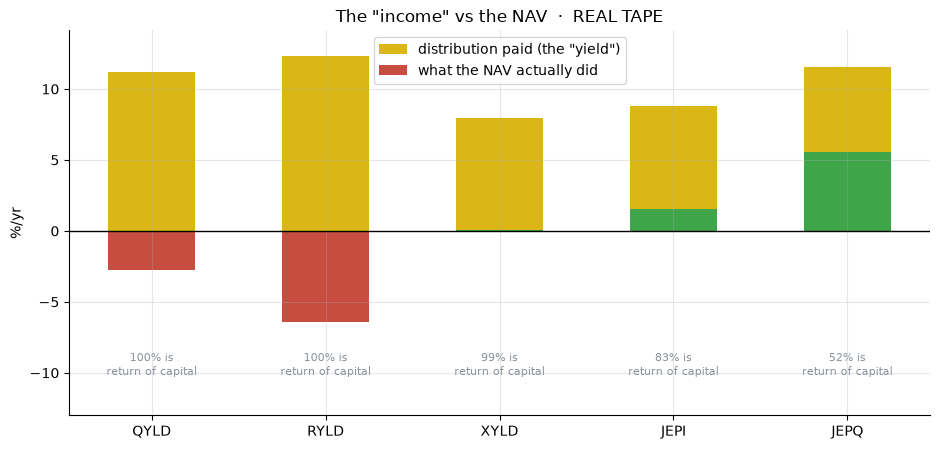

fund  dist%  price_cagr%  roc%
QYLD   11.2         -2.7 100.0
RYLD   12.3         -6.4 100.0
XYLD    8.0          0.1  99.3
JEPI    8.8          1.5  82.7
JEPQ   11.5          5.6  51.6


In [2]:
rows = []
if HAVE_REAL and not SPLIT.empty:
    for f in ['QYLD','RYLD','XYLD','JEPI','JEPQ']:
        try:
            both = pd.concat([SPLIT[(f,'price')], SPLIT[(f,'dist')]], axis=1).dropna()
        except KeyError:
            continue
        ill = st.income_illusion(both.iloc[:,0], both.iloc[:,1])
        rows.append((f, ill['dist_yield']*100, ill['price_cagr']*100, ill['return_of_capital_share']*100))
    src = 'REAL TAPE'
if not rows:
    rows = [('QYLD',R['qyld_dist'],R['qyld_price'],R['qyld_roc']*100),
            ('RYLD',R['ryld_dist'],R['ryld_price'],R['ryld_roc']*100),
            ('XYLD',R['xyld_dist'],R['xyld_price'],R['xyld_roc']*100),
            ('JEPI',R['jepi_dist'],R['jepi_price'],R['jepi_roc']*100),
            ('JEPQ',R['jepq_dist'],R['jepq_price'],R['jepq_roc']*100)]
    src = 'frozen real numbers (docs/results.md)'
dfi = pd.DataFrame(rows, columns=['fund','dist%','price_cagr%','roc%'])
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(dfi))
ax.bar(x, dfi['dist%'], width=.5, color=AMBER, label='distribution paid (the "yield")')
ax.bar(x, dfi['price_cagr%'], width=.5, color=[GREEN if v>=0 else RED for v in dfi['price_cagr%']],
       alpha=.9, label='what the NAV actually did')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(dfi['fund'])
ax.set_ylabel('%/yr'); ax.legend()
ax.set_title(f'The "income" vs the NAV  ·  {src}')
for xi, r_ in zip(x, dfi['roc%']):
    ax.annotate(f'{r_:.0f}% is\nreturn of capital', (xi, -8.5), ha='center', va='top', fontsize=8, color=GREY)
ax.set_ylim(-13, max(dfi['dist%'])*1.15)
plt.tight_layout(); plt.show()
print(dfi.round(1).to_string(index=False))

For **QYLD** and **RYLD** the bar is brutal: they paid 11% and 12% 'yields' while their NAV *shrank* — so the entire distribution was **return of capital**, your own money on a round trip. Even the better-run **JEPI** is ~83% return of capital. The 'income' is real cash, but it's overwhelmingly principal and gains you already had, not yield created out of thin air.

**Now the race.** Forget the yield for a second — what matters is total return. Here's each fund vs just owning SPY (total return, fees and all), per year over its life:

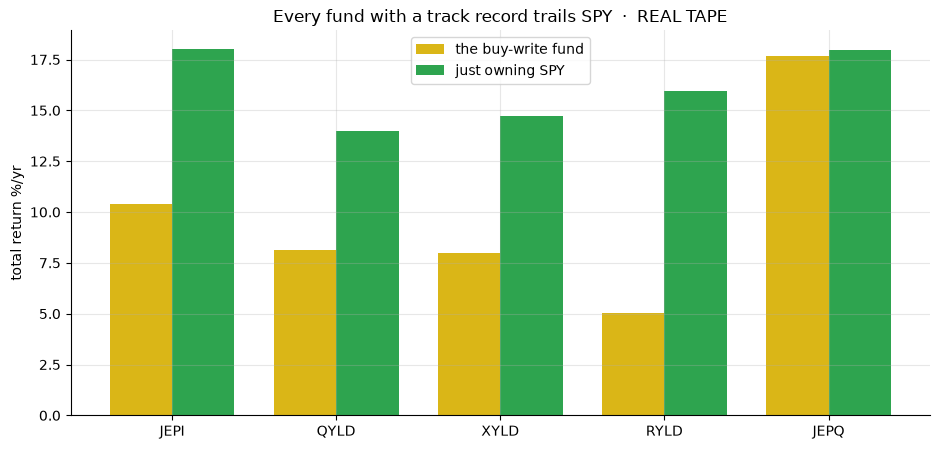

fund  fund_cagr  spy_cagr
JEPI       10.4      18.0
QYLD        8.1      14.0
XYLD        8.0      14.7
RYLD        5.0      16.0
JEPQ       17.7      18.0


In [3]:
if HAVE_REAL:
    rr = []
    for f in ['JEPI','QYLD','XYLD','RYLD','JEPQ']:
        sub = PANEL[[f,'SPY']].dropna()
        if sub.empty: continue
        r = st.race(sub[f], sub['SPY'])
        rr.append((f, r['fund_cagr']*100, r['bench_cagr']*100))
    src = 'REAL TAPE'
else:
    rr = [('JEPI',R['jepi_cagr'],18.0),('QYLD',R['qyld_cagr'],14.0),
          ('XYLD',R['xyld_cagr'],14.7),('RYLD',R['ryld_cagr'],16.0),('JEPQ',R['jepq_cagr'],18.0)]
    src = 'frozen real numbers (docs/results.md)'
dfr = pd.DataFrame(rr, columns=['fund','fund_cagr','spy_cagr'])
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(dfr)); w=.38
ax.bar(x-w/2, dfr['fund_cagr'], w, color=AMBER, label='the buy-write fund')
ax.bar(x+w/2, dfr['spy_cagr'], w, color=GREEN, label='just owning SPY')
ax.set_xticks(x); ax.set_xticklabels(dfr['fund']); ax.set_ylabel('total return %/yr')
ax.legend(); ax.set_title(f'Every fund with a track record trails SPY  ·  {src}')
plt.tight_layout(); plt.show()
print(dfr.round(1).to_string(index=False))

Green beats amber almost everywhere. QYLD trailed SPY by ~6%/yr, JEPI by ~8%/yr, RYLD by ~11%/yr — and all at a *lower* Sharpe (more on that for the quants). The one near-tie, **JEPQ**, only exists because it was born into a roaring Nasdaq bull market that its options barely capped — a lucky 4-year window, not a vindicated design.

**Why does holding the market lose to the market?** Because covered calls **cap your upside**. Here's the up-vs-down capture of the systematic writers — how much of the good months and the bad months they keep:

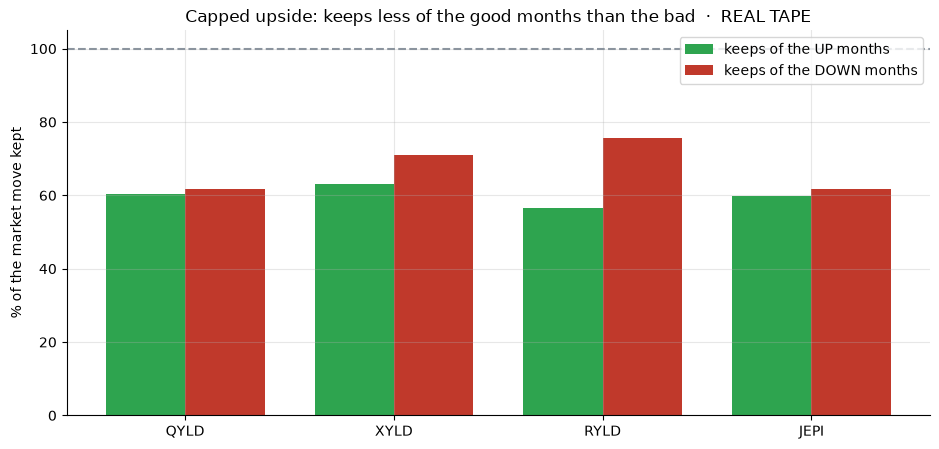

fund   up   dn
QYLD 0.60 0.62
XYLD 0.63 0.71
RYLD 0.57 0.76
JEPI 0.60 0.62


In [4]:
if HAVE_REAL:
    cc = []
    for f in ['QYLD','XYLD','RYLD','JEPI']:
        sub = PANEL[[f,'SPY']].dropna()
        if sub.empty: continue
        c = st.capture(sub[f], sub['SPY'])
        cc.append((f, c['up_capture'], c['down_capture']))
    src='REAL TAPE'
else:
    cc=[('QYLD',R['qyld_up'],R['qyld_dn']),('XYLD',R['xyld_up'],R['xyld_dn']),
        ('RYLD',R['ryld_up'],R['ryld_dn']),('JEPI',R['jepi_up'],R['jepi_dn'])]
    src='frozen real numbers (docs/results.md)'
dfc = pd.DataFrame(cc, columns=['fund','up','dn'])
fig, ax = plt.subplots(figsize=(9.5,4.6))
x=np.arange(len(dfc)); w=.38
ax.bar(x-w/2, dfc['up']*100, w, color=GREEN, label='keeps of the UP months')
ax.bar(x+w/2, dfc['dn']*100, w, color=RED, label='keeps of the DOWN months')
ax.axhline(100, ls='--', c=GREY); ax.set_xticks(x); ax.set_xticklabels(dfc['fund'])
ax.set_ylabel('% of the market move kept'); ax.legend()
ax.set_title(f'Capped upside: keeps less of the good months than the bad  ·  {src}')
plt.tight_layout(); plt.show()
print(dfc.round(2).to_string(index=False))

There's the mechanism in one picture. You keep only ~60% of the rallies but ~62–76% of the sell-offs. The call premium you collect simply doesn't pay for the upside you hand away — so over a full cycle you fall behind.

## 5 · The verdict

- **Signal — Real.** Every fund with a real history trails SPY total return with a strong statistical *t* (QYLD −3.2, XYLD −3.8, RYLD −2.9, JEPI −2.1), and the distribution is 83–100% return of capital. The under-performance and the income illusion are real, not noise.
- **Tradability — Mirage.** As a way to *own equities* it's strictly worse: lower Sharpe, capped upside, and a 'yield' that's mostly self-financed.
- **Yield without giving up returns? — Busted.** You give up the returns to *manufacture* the yield. The promise is precisely what the data refutes.

## 6 · Could you actually trade it?

You can absolutely *buy* these funds — they're liquid and cheap to trade. The question is whether you *should*, and for what. As a high-cash-flow sleeve in a taxable bucket where you genuinely want spendable cash and accept lower growth, a buy-write is a defensible (if expensive) tool. As a 'better way to own the market' or a retirement growth engine, it's the wrong instrument: you'd have ended up with more money — and could have *sold shares* for the same cash flow with more control — by just holding a low-cost index fund. The cash isn't fake; the **free lunch** is.

## 7 · Going further 🚪

- **The sister study.** [Study 62 — Premium-Seller](../../62-premium-seller/) races QYLD against *its own underlying* (QQQ) and dissects the capture asymmetry — the same family, a different cut.
- **The dividend cousin.** [Study 57 — Yield-Trap](../../57-yield-trap/): high-dividend *stocks* on total return — the same 'the yield isn't free' lesson on single names.
- **Fork it.** Does the buy-write win in a flat, choppy decade (when the upside it caps never shows up)? Re-run the race over only sideways sub-periods and see whether the premium finally pays — the one regime where the pitch could be true.

*Think JEPQ proves the new generation cracked it? Fork this, wait for the next bear market, and re-run the race — the design's whole claim is that it protects you then.*